<a href="https://colab.research.google.com/github/LunaGar1/Pratica2-Vision-e-IA/blob/main/P2_reto6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reto 6: Clasificación Perros y Gatos

### Importar librerías

In [ ]:
import pandas as pd
import numpy as np
import os as os
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from skimage.transform import resize
from skimage.io import imread
from skimage.color import gray2rgb, rgba2rgb
from skimage.color import rgb2hsv, rgb2gray
from skimage.feature import graycomatrix, graycoprops
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Extraccion de descriptores

### Traer y transformar Dataset Cats&Dogs

In [ ]:
def extraer_caracteristicas(img_array):
    rgb_mean = img_array.mean(axis=(0, 1))
    rgb_std = img_array.std(axis=(0, 1))
    hsv = rgb2hsv(img_array)
    hsv_mean = hsv.mean(axis=(0, 1))
    hsv_std = hsv.std(axis=(0, 1))
    gray = (rgb2gray(img_array) * 255).astype(np.uint8)
    glcm = graycomatrix(gray, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                         levels=256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, "contrast").mean()
    homogeneity = graycoprops(glcm, "homogeneity").mean()
    energy = graycoprops(glcm, "energy").mean()
    correlation = graycoprops(glcm, "correlation").mean()
    dissimilarity = graycoprops(glcm, "dissimilarity").mean()
    ASM = graycoprops(glcm, "ASM").mean()
    return np.hstack([rgb_mean, rgb_std, hsv_mean, hsv_std,
                       contrast, homogeneity, energy, correlation, dissimilarity, ASM])

## Cargar imagenes: pixeles crudos

In [ ]:
path = "/content/drive/MyDrive/VisionComputadorIA/Dataset500/PetImages"
print(os.listdir(path))

['Dog', 'Cat']


In [ ]:
Categories = ["Dog", "Cat"]
LIMITE = 500
flat_data_arr = []
target_arr = []
datadir = path

for i in Categories:
    print(f"Loading... Category: {i}")
    category_path = os.path.join(datadir, i)
    count = 0
    for img in os.listdir(category_path):
        if count >= LIMITE:
            break
        try:
            img_array = imread(os.path.join(category_path, img))
            if len(img_array.shape) == 2:
                img_array = np.stack((img_array,) * 3, axis=-1)
            if img_array.shape[2] == 4:
                img_array = img_array[:, :, :3]
            img_resized = resize(img_array, (64, 64))
            flat_data_arr.append(img_resized.flatten())
            target_arr.append(Categories.index(i))
            count += 1
        except:
            continue
    print(f"Loaded category: {i} successfully")

Loading... Category: Dog
Loaded category: Dog successfully
Loading... Category: Cat
Loaded category: Cat successfully


In [ ]:
print(f"{len(flat_data_arr)} x {len(flat_data_arr[0])}")
print(len(target_arr))
print("Dogs:", target_arr.count(0))
print("Cats:", target_arr.count(1))

999 x 12288
999
Dogs: 500
Cats: 499


In [ ]:
flat_data = np.array(flat_data_arr)
target = np.array(target_arr)

In [ ]:
df = pd.DataFrame(flat_data)
df["Target"] = target
df.shape
df

,0,1,2,3,4,5,6,7,8,9,...,12279,12280,12281,12282,12283,12284,12285,12286,12287,Target
0,0.134852,0.125234,0.044295,0.166741,0.161003,0.050258,0.218834,0.216140,0.085516,0.371422,...,0.023723,0.023723,0.015881,0.023132,0.023132,0.015293,0.027446,0.027446,0.019603,0
1,0.415185,0.538187,0.424680,0.361606,0.466962,0.343982,0.390788,0.480597,0.334794,0.484646,...,0.689604,0.694244,0.605462,0.634639,0.628123,0.555417,0.664161,0.652743,0.608161,0
2,0.542441,0.558135,0.605192,0.541008,0.559732,0.605971,0.495537,0.529310,0.571055,0.556745,...,0.654036,0.667374,0.678609,0.637783,0.659844,0.670666,0.566736,0.575030,0.575892,0
3,0.516633,0.555851,0.591144,0.525786,0.566241,0.601122,0.529269,0.578491,0.610450,0.542216,...,0.184523,0.193468,0.237071,0.164150,0.175523,0.207014,0.150281,0.162045,0.183477,0
4,0.999984,0.999985,0.999985,0.999407,0.999606,0.999515,0.983326,0.988010,0.985915,0.917212,...,0.957412,0.961168,0.959330,0.995201,0.997510,0.996552,0.999864,0.999958,0.999922,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,0.547939,0.443444,0.326192,0.530152,0.431219,0.315948,0.482050,0.375967,0.268067,0.425637,...,0.610812,0.537414,0.473583,0.606948,0.533651,0.468586,0.587696,0.514377,0.454408,1
995,0.705816,0.527218,0.498263,0.766487,0.551252,0.491339,0.826029,0.593885,0.487374,0.880953,...,0.137640,0.127884,0.111329,0.137125,0.117590,0.102010,0.147445,0.124245,0.109752,1
996,0.432123,0.455677,0.469942,0.434481,0.451154,0.459058,0.455525,0.470660,0.477284,0.490734,...,0.131569,0.137351,0.097890,0.141147,0.145411,0.112189,0.147720,0.151730,0.126367,1
997,0.035816,0.038067,0.026394,0.032383,0.034729,0.023453,0.031317,0.034488,0.027468,0.031062,...,0.084016,0.085694,0.071975,0.097250,0.100054,0.069283,0.129699,0.130772,0.083151,1


Cargar imagenes:Descriptores

In [ ]:
feat_data_arr = []
target_arr2 = []

for i in Categories:
    print(f"Loading (features)... Category: {i}")
    category_path = os.path.join(datadir, i)
    count = 0
    for img in os.listdir(category_path):
        if count >= LIMITE:
            break
        try:
            img_array = imread(os.path.join(category_path, img))
            if len(img_array.shape) == 2:
                img_array = np.stack((img_array,) * 3, axis=-1)
            if img_array.shape[2] == 4:
                img_array = img_array[:, :, :3]
            img_resized = resize(img_array, (64, 64))
            features = extraer_caracteristicas(img_resized)
            feat_data_arr.append(features)
            target_arr2.append(Categories.index(i))
            count += 1
        except Exception:
            continue
    print(f"Loaded (features) category: {i} successfully")

feat_data = np.array(feat_data_arr)
target2 = np.array(target_arr2)
df_feat = pd.DataFrame(feat_data)
df_feat["Target"] = target2
print(f"Shape con descriptores: {df_feat.shape}")  # (1000, 23) aprox., vs (1000, 12289) original

Loading (features)... Category: Dog
Loaded (features) category: Dog successfully
Loading (features)... Category: Cat
Loaded (features) category: Cat successfully
Shape con descriptores: (999, 19)


### Separar X, Y, entrenamiento y pruebas

In [ ]:
X = df.drop(columns=["Target"]).copy()
y = df["Target"].copy()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=28, stratify=y)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Entrenar modelo y predicciones

In [ ]:
modelo = SVC()
modelo.fit(X_train, y_train)

SVC()

In [ ]:
pred = modelo.predict(X_test)

### Validaciones

Precision: 0.6166666666666667

Classification Report:
               precision    recall  f1-score   support

         Dog       0.60      0.68      0.64       150
         Cat       0.63      0.55      0.59       150

    accuracy                           0.62       300
   macro avg       0.62      0.62      0.62       300
weighted avg       0.62      0.62      0.62       300



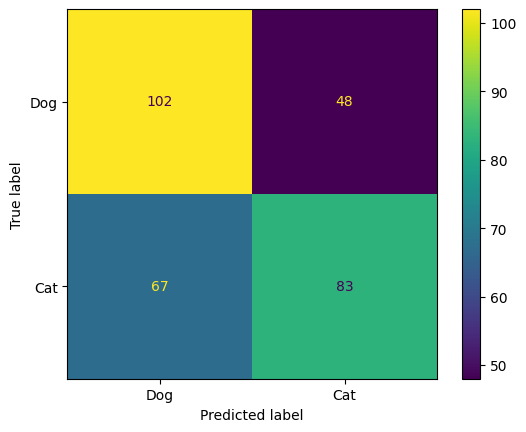

In [ ]:
precision = accuracy_score(y_test, pred)
reporte = classification_report(y_test, pred, target_names=Categories)

print("Precision:", precision)
print("\nClassification Report:\n", reporte)

ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=Categories)

Grid search

Fitting 2 folds for each of 36 candidates, totalling 72 fits
Mejores hiperparámetros: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'} con precisión: 0.583679901760131
Precision del mejor modelo (SVC, píxeles): 0.61

Classification Report:
               precision    recall  f1-score   support

         Dog       0.61      0.63      0.62       150
         Cat       0.61      0.59      0.60       150

    accuracy                           0.61       300
   macro avg       0.61      0.61      0.61       300
weighted avg       0.61      0.61      0.61       300



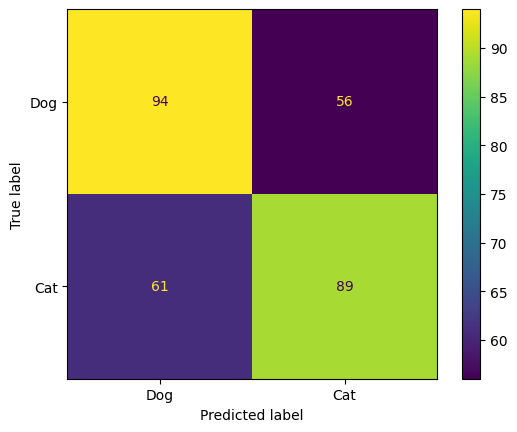

In [ ]:
param_grid = [
    {"kernel": ["linear"], "C": [0.1, 1, 10, 100]},
    {"kernel": ["rbf", "poly"], "C": [0.1, 1, 10, 100], "gamma": ["scale", 0.1, 0.01, 0.001]},
]

grid = GridSearchCV(SVC(), param_grid, cv=2, scoring="accuracy", n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print(f"Mejores hiperparámetros: {grid.best_params_} con precisión: {grid.best_score_}")

mejor_modelo = grid.best_estimator_
y_pred_mejor = mejor_modelo.predict(X_test)

precision_mejor = accuracy_score(y_test, y_pred_mejor)
reporte_mejor = classification_report(y_test, y_pred_mejor, target_names=Categories)
print("Precision del mejor modelo (SVC, píxeles):", precision_mejor)
print("\nClassification Report:\n", reporte_mejor)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mejor, display_labels=Categories)

## Prediccion de una imagen aleatoria

(np.float64(-0.5), np.float64(156.5), np.float64(199.5), np.float64(-0.5))

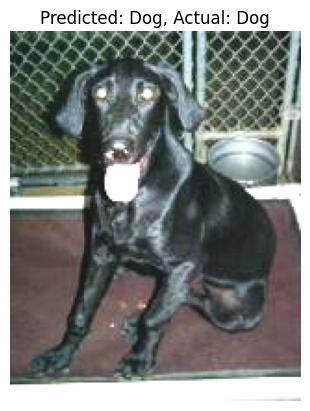

In [ ]:
category = random.choice(Categories)
folder = os.path.join(datadir, category)
img_name = random.choice(os.listdir(folder))
img_path = os.path.join(folder, img_name)
img = imread(img_path)
if len(img.shape) == 2:
    img = np.stack((img,) * 3, axis=-1)
if img.shape[2] == 4:
    img = img[:, :, :3]
img_resized = resize(img, (64, 64))
img_flat = img_resized.flatten().reshape(1, -1)
prediction = mejor_modelo.predict(img_flat)[0]
plt.imshow(img)
plt.title(f"Predicted: {Categories[prediction]}, Actual: {category}")
plt.axis("off")

## SVC con descriptores

Fitting 2 folds for each of 36 candidates, totalling 72 fits
Mejores hiperparámetros (descriptores): {'C': 0.1, 'kernel': 'linear'} con precisión: 0.6351780597625869
Precision SVC (descriptores): 0.6333333333333333
              precision    recall  f1-score   support

         Dog       0.65      0.58      0.61       150
         Cat       0.62      0.69      0.65       150

    accuracy                           0.63       300
   macro avg       0.63      0.63      0.63       300
weighted avg       0.63      0.63      0.63       300



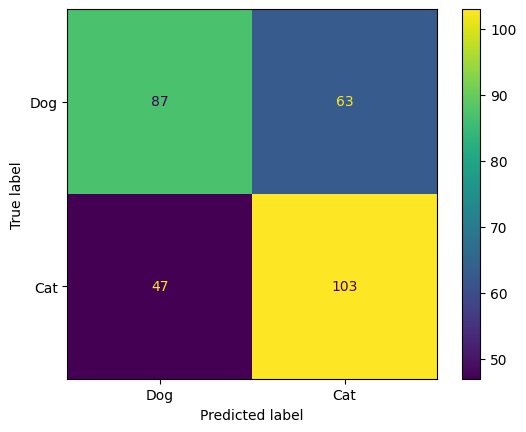

In [ ]:
X2 = df_feat.drop(columns=["Target"]).copy()
y2 = df_feat["Target"].copy()
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.3, random_state=28, stratify=y2)

scaler2 = StandardScaler()
X_train2 = scaler2.fit_transform(X_train2)
X_test2 = scaler2.transform(X_test2)

grid2 = GridSearchCV(SVC(), param_grid, cv=2, scoring="accuracy", n_jobs=-1, verbose=1)
grid2.fit(X_train2, y_train2)

print(f"Mejores hiperparámetros (descriptores): {grid2.best_params_} con precisión: {grid2.best_score_}")

pred2 = grid2.best_estimator_.predict(X_test2)
print("Precision SVC (descriptores):", accuracy_score(y_test2, pred2))
print(classification_report(y_test2, pred2, target_names=Categories))
ConfusionMatrixDisplay.from_predictions(y_test2, pred2, display_labels=Categories)

In [ ]:
category = random.choice(Categories)
folder = os.path.join(datadir, category)
img_name = random.choice(os.listdir(folder))
img_path = os.path.join(folder, img_name)
img = imread(img_path)
if len(img.shape) == 2:
    img = np.stack((img,) * 3, axis=-1)
if img.shape[2] == 4:
    img = img[:, :, :3]
img_resized = resize(img, (64, 64))
img_flat = img_resized.flatten().reshape(1, -1)
prediction = mejor_modelo.predict(img_flat)[0]
plt.imshow(img)
plt.title(f"Predicted: {Categories[prediction]}, Actual: {category}")

## KNN

Precision KNN (default): 0.54
              precision    recall  f1-score   support

         Dog       0.55      0.48      0.51       150
         Cat       0.54      0.60      0.57       150

    accuracy                           0.54       300
   macro avg       0.54      0.54      0.54       300
weighted avg       0.54      0.54      0.54       300



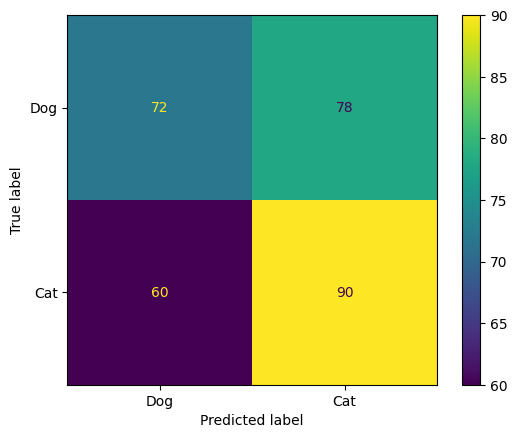

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Separar datos (igual que hacías con RF, pero KNN sí necesita escalado)
X_knn = df.drop(columns=["Target"]).copy()
y_knn = df["Target"].copy()
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X_knn, y_knn, test_size=0.3, random_state=28, stratify=y_knn)

scaler_knn = StandardScaler()
X_train_knn = scaler_knn.fit_transform(X_train_knn)
X_test_knn = scaler_knn.transform(X_test_knn)

# Modelo default
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_knn, y_train_knn)
pred_knn = knn_model.predict(X_test_knn)

precision_knn = accuracy_score(y_test_knn, pred_knn)
print("Precision KNN (default):", precision_knn)
print(classification_report(y_test_knn, pred_knn, target_names=Categories))
ConfusionMatrixDisplay.from_predictions(y_test_knn, pred_knn, display_labels=Categories)

## Grid search

In [ ]:
param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring="accuracy", n_jobs=-1, verbose=1)
grid_knn.fit(X_train_knn, y_train_knn)

print(f"Mejores hiperparámetros KNN: {grid_knn.best_params_} con precisión: {grid_knn.best_score_}")

pred_knn_grid = grid_knn.best_estimator_.predict(X_test_knn)
print("Precision KNN (grid):", accuracy_score(y_test_knn, pred_knn_grid))
print(classification_report(y_test_knn, pred_knn_grid, target_names=Categories))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros KNN: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'} con precisión: 0.5765775950668036
Precision KNN (grid): 0.59
              precision    recall  f1-score   support

         Dog       0.62      0.47      0.53       150
         Cat       0.57      0.71      0.64       150

    accuracy                           0.59       300
   macro avg       0.60      0.59      0.58       300
weighted avg       0.60      0.59      0.58       300



## Regresion logistica

Precision Logistic Regression (default): 0.5833333333333334

Classification Report:
               precision    recall  f1-score   support

         Dog       0.58      0.62      0.60       150
         Cat       0.59      0.55      0.57       150

    accuracy                           0.58       300
   macro avg       0.58      0.58      0.58       300
weighted avg       0.58      0.58      0.58       300



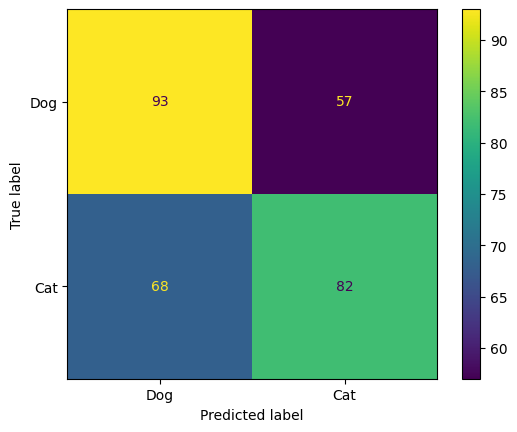

In [ ]:
log_model = LogisticRegression(random_state=28, max_iter=1000)
log_model.fit(X_train, y_train)
pred_lr = log_model.predict(X_test)

precision_lr = accuracy_score(y_test, pred_lr)
reporte_lr = classification_report(y_test, pred_lr, target_names=Categories)

print("Precision Logistic Regression (default):", precision_lr)
print("\nClassification Report:\n", reporte_lr)
ConfusionMatrixDisplay.from_predictions(y_test, pred_lr, display_labels=Categories)

## Grid search

Mejores hiperparámetros LR: {'C': 100, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'} con precisión: 0.5478725590955806
Precision LR (grid): 0.5533333333333333
              precision    recall  f1-score   support

         Dog       0.55      0.59      0.57       150
         Cat       0.56      0.52      0.54       150

    accuracy                           0.55       300
   macro avg       0.55      0.55      0.55       300
weighted avg       0.55      0.55      0.55       300



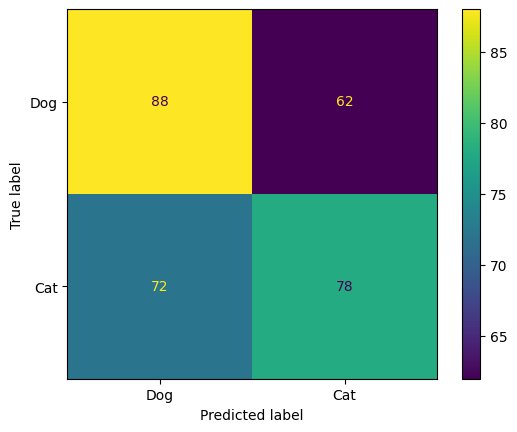

In [ ]:
param_grid_lr = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"],
    "max_iter": [1000]
}

grid_lr = GridSearchCV(LogisticRegression(random_state=28), param_grid_lr, cv=5, scoring="accuracy", n_jobs=-1)
grid_lr.fit(X_train, y_train)

print(f"Mejores hiperparámetros LR: {grid_lr.best_params_} con precisión: {grid_lr.best_score_}")

pred_lr_grid = grid_lr.best_estimator_.predict(X_test)
print("Precision LR (grid):", accuracy_score(y_test, pred_lr_grid))
print(classification_report(y_test, pred_lr_grid, target_names=Categories))
ConfusionMatrixDisplay.from_predictions(y_test, pred_lr_grid, display_labels=Categories)

## Comparacion de resultados

In [ ]:
resultados = pd.DataFrame({
    "Modelo": [
        "SVC default (píxeles)",
        "SVC grid (píxeles)",
        "SVC grid (descriptores)",
        "KNN default",
        "KNN grid",
        "Logistic Regression default",
        "Logistic Regression grid",
    ],
    "Accuracy (test)": [
        precision,
        accuracy_score(y_test, grid.best_estimator_.predict(X_test)),
        accuracy_score(y_test2, grid2.best_estimator_.predict(X_test2)),
        precision_knn,
        accuracy_score(y_test_knn, grid_knn.best_estimator_.predict(X_test_knn)),
        precision_lr,
        accuracy_score(y_test, grid_lr.best_estimator_.predict(X_test)),
    ]
})

resultados = resultados.sort_values("Accuracy (test)", ascending=False).reset_index(drop=True)
print(resultados)

                        Modelo  Accuracy (test)
0      SVC grid (descriptores)         0.633333
1        SVC default (píxeles)         0.616667
2           SVC grid (píxeles)         0.610000
3                     KNN grid         0.590000
4  Logistic Regression default         0.583333
5     Logistic Regression grid         0.553333
6                  KNN default         0.540000


## Conclusiones
1. SVC con descriptores obtuvo el mejor resultado (63.3%), superando incluso a SVC con píxeles crudos (61.0%). Reducir de 12,288 a ~22 características no perdió información relevante — la mejoró, evitando el sobreajuste típico de alta dimensionalidad con pocos datos (700 muestras).
2. SVC fue el modelo más robusto en todas sus variantes, gracias a su capacidad de encontrar fronteras de decisión no lineales (kernel rbf), superando a KNN y Logistic Regression consistentemente.
3. KNN fue el modelo más débil (54.0%-59.0%). Con píxeles crudos, la distancia entre imágenes no refleja bien su similitud real (iluminación, pose, fondo distorsionan la métrica), lo que perjudica directamente su lógica de vecinos cercanos.
4. El grid search no siempre mejoró el resultado en test: ayudó claramente a KNN (+5 pp), pero fue marginal o negativo en SVC y Logistic Regression — el tipo de representación de la imagen (descriptores vs. píxeles) tuvo más impacto que el ajuste de hiperparámetros.
5. Ningún modelo superó el 65% de accuracy, mostrando el techo de los métodos clásicos de ML (sin deep learning) frente a un problema visual complejo como distinguir razas, poses y fondos variados de perros y gatos.